##Parâmetros da Simulação

In [1]:
import numpy as np
import random
K= 512 #tamanho da chave
L = 412  #tamanho da tag e da mensagem
N = 10**3
rho_s = np.sqrt(0.985)  # alocação de potência para a mensagem
snr_db = 10
eta = 0.0000001 #maior tolerancia

# Mensagem e Modulação BPSK#


In [2]:
#mensagem modulada de comprimento K com alfabeto de [1,-1]
def modulator_bpsk(L, seed=None):
    s_bin = np.random.randint(0, 2, size=L)
    s_bpsk = 1 - 2 * s_bin  # mapeia 0→+1, 1→-1
    return s_bin, s_bpsk


#Geração das TAGs


In [3]:
a, b, c = 6, 1, 1
def Mfunc(x, K):
    return (a * x**2 + b * x + c) % (2**K)
#def tentmap(x):
#    if -1 <= x < 0:
#        return 2 * x + 0.9999
#    elif 0 <= x <= 1:
#        return -2 * x + 0.9999
#    else:
#        return 0  # fora do domínio esperado

def tentmap(x, beta=0.000001):
    if x == None: #condição inicial
        x = np.random.uniform(-1, 1) #escolhida aleatoriamente neste caso
    if x < beta:
        return 2/(beta+1)*x + (1-beta)/(beta+1) #~ 2x +1
    else:
        return 2/(beta-1)*x - (beta+1)/(beta-1) #~ 2x -1
def orbit(x0, steps):
    x = x0
    xorbit=[] #ponto inicial S0_(y)
    for i in range(steps):
        x = tentmap(x)
        xorbit.append(x)
    return xorbit

# Geração de TAG de comprimento L com 1 órbita por símbolo
def generate_tag(L, K, bits_msg, chave,x0=None):
    sigma = K - L  # pontos a descartar
    steps_total = K
    tags = []
    #Condicao inicial
    if x0 == None: #geração legitima
      #k_repeated = np.resize(k, L)
      m_filled = np.resize(bits_msg,K) #extende a mensagem para o mesmo tamanho da chave
      s_xor_k = np.bitwise_xor(m_filled, chave)
      # Converte vetor binário para inteiro
      xor_value = int("".join(str(b) for b in s_xor_k), 2)
      xi = Mfunc(xor_value, K=K)
      x0_norm =  (xi / (2**K - 1)) * 2 - 1  # normaliza para [-1, 1] # para que fique no alfabeto do mapa da tenda
    else:
      xi =x0 #geração falsa
      #x0_norm =  (xi / (2**K - 1)) * 2 - 1  # normaliza para [-1, 1] # para que fique no alfabeto do mapa da tenda
    #gera orbita completa
    orb = orbit(x0, K) # Iterar sigma + L vezes
    orb_descarte = orb[sigma:]  # descarta os sigma pontos
    return np.array(orb_descarte)


In [4]:
chave= np.random.randint(0, 2, K)
bits_msg, bpsk_msg = modulator_bpsk(L)
#x0 = np.random.uniform(-1, 1) #condicao inicial fake para teste
tag = generate_tag(L, K, bits_msg, chave) #tag fake

print("Media:", np.mean(tag))
print("Variancia :", np.var(tag))
print("Media do quadrado:", np.mean(tag**2))
#print(x0)


Media: 0.02184527567744229
Variancia : 0.31884440198624475
Media do quadrado: 0.31932161805566817


In [5]:
chave= np.random.randint(0, 2, K)
bits_msg, bpsk_msg = modulator_bpsk(L)
x0 = np.random.uniform(-1, 1) #condicao inicial fake para teste
tag_fake = generate_tag(L, K, bits_msg, chave, x0) #tag fake
print("Media:", np.mean(tag_fake))
print("Variancia :", np.var(tag_fake))
print("Media do quadrado:", np.mean(tag_fake**2))
#print(x0)
print("correlação:", np.sum(tag_fake*tag))


Media: -0.0029083532779180985
Variancia : 0.335440963618883
Media do quadrado: 0.33544942213767204
correlação: -6.543055450503377


#Transmissão#


In [6]:
# --- Energia da TAG ---
def compute_tag_power( tag): #é necessario calcular potencia da tag, seja ela legitima ou falsa
    """
    Calcula a energia média de uma única tag (um vetor).
    """
    return np.mean(tag**2)


# --- Combina mensagem e tag ---
def combine_message_tag(s, tag, rho_s):
    """
    Combina uma mensagem BPSK (s) e uma tag (tag) em um único sinal x.
    """
    Ptag = compute_tag_power(tag)   # E[tag^2]
    rho_t = np.sqrt((1 - rho_s**2) / Ptag)  # normalização pela energia da tag

    # Combinação direta (mesmo tamanho: 1 símbolo de s ↔ 1 símbolo de tag)
    s = np.array(s)
    tag = np.array(tag)
    x = rho_s * s + rho_t * tag

    return x, rho_t


# --- Ruído AWGN ---
def gen_noise(snr_db, N):
    """
    Gera ruído gaussiano branco de tamanho N para um SNR dado.
    """
    snr_linear = 10**(snr_db / 10)
    Es = 1  # energia média do BPSK fixada
    sigma2w = Es / snr_linear  # variância do ruído
    noise = np.random.normal(0, np.sqrt(sigma2w), N)
    return sigma2w, noise


# --- Canal AWGN ---
def add_awgn(x, snr_db):
    """
    Adiciona ruído AWGN a um único sinal x.
    """
    sigma2w, noise = gen_noise(snr_db, len(x))
    y = x + noise
    return y, noise


##Recepção

In [7]:
def detect_tag(y, s, t_ref, rho_s, rho_t):
    """
    Calcula a estatística de decisão para UMA transmissão.
    """
    # Remove a contribuição da mensagem
    y_minus_msg = (y - rho_s * s) / rho_t

    # Correlação com TAG legítima (esperada)
    stat = np.sum(y_minus_msg * t_ref)

    return stat


# Limiar de decisão e Matriz de Confusão

In [8]:
#Decodificador da dissertação:
from scipy.stats import norm
from scipy.special import erfc
import pytest

def Qfunc(x):
    """ Q function """
    return (0.5)*erfc(x/np.sqrt(2))

def thresh(stdDev,mean,alpha):
#    """ Finds the decision threshold for the hypothesis test """
    threshold = 0
    while Qfunc((threshold-mean)/stdDev) > alpha:
        threshold += 0.1
    return threshold
#def thresh(stdDev, mean, alpha):
#    return norm.isf(alpha) * stdDev + mean

#def thresh(std, mean, alpha):
#    return mean + std * norm.isf(alpha)

def tauVarCalc(sigma2w,len_message,rho_t, tag):
    sigma2tag = np.var(tag) #continua sendo a variancia da tag legitima
    #assert sigma2tag == compute_tag_power(tags), "Mismatch energy and var"
    #assert abs(sigma2tag - compute_tag_power(tag)) < 1e-3
    tauVar = (sigma2tag*sigma2w*len_message)/(rho_t**2)
    return tauVar

def threshold_decision(sigma2w, len_message, rhot,tag, eta,mu):
    """
    Decide entre H1 (TAG legítima) e H0 (sem TAG ou falsa),
    com base no limiar calculado pela expressão:
    Q(tau_i / sigma^2_vi) < eta
    """
    sigma2_v= tauVarCalc(sigma2w,len_message, rhot,tag)
    # Encontrar o menor τ_0 tal que Q(τ_0 / σ²_vi) < η
    tau0 = thresh(np.sqrt(sigma2_v), mu, eta) #mu é o valor esperado de tau|H0, ou seja: np.sum(tag_fake*tag_legit)
    return tau0


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def compute_confusion_matrix(stat_H1, stat_H0, tau):

    y_true = np.concatenate([np.ones(len(stat_H1)), np.zeros(len(stat_H0))])
    y_scores = np.concatenate([stat_H1, stat_H0])

    # Se tau for um único valor, repete para todas as transmissões
    if np.isscalar(tau):
        tau_vec = np.full_like(y_scores, fill_value=tau, dtype=float)
    else:
        tau_vec = np.array([tau[i % len(tau)] for i in range(len(y_scores))])

    # Aplica thresholds por transmissão
    y_pred = (y_scores >= tau_vec).astype(int)

    # Matriz de confusão
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    TN, FP, FN, TP = cm.ravel()

    cm_normalized = cm.astype('float') / len(stat_H0)

    print(f"TP: {TP/len(stat_H1):.3f}, FP: {FP/len(stat_H0):.3f}, TN: {TN/len(stat_H0)}, FN: {FN/len(stat_H1):.3f}")
    print(f"Accuracy: {(TP + TN) / len(y_true):.3f}")
    print(f"False Positive Rate: {FP:.3f}")
    print(f"False Negative Rate: {FN:.3f}")

    # Exibe a matriz
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=["H0", "H1"])
    disp.plot(cmap='Blues')
    plt.grid(False)
    plt.title("Matriz de Confusão")
    plt.show()


#Teste de Hipótese

In [ ]:
#decisão
#H1: tag presente
#H0: sem tag
def simulate_hypothesis_test(L, K, N, rho_s, snr_db, chave,sigma2w,eta):
    all_stat_H1 = []
    all_stat_H0 = []
    tau_vec = []

    for n in range(N):
        # --- 1. Mensagem e modulação ---
        bits_msg, bpsk_msg = modulator_bpsk(L)

        # --- 2. Geração da TAG legítima ---
        tag_legit = generate_tag(L, K, bits_msg, chave)

        # --- 3. Combinação mensagem + TAG legítima ---
        x_tag, rho_t = combine_message_tag(bpsk_msg, tag_legit, rho_s)

        # --- 4. Canal AWGN para H1 ---
        y_legit, noise = add_awgn(x_tag, snr_db)

        # --- 5. Decisão sob H1 ---
        tau_H1 = detect_tag(y_legit, bpsk_msg, tag_legit, rho_s, rho_t)

        # --- 6. Geração de mensagem com tag falsa  (hipótese H0) ---
        x0 = np.random.uniform(-1, 1) #escolhida aleatoriamente neste caso
        tag_fake = generate_tag(L, K, bits_msg, chave,x0) #gerando tag com outra condição inicial
        # --- 7. Combinação mensagem + TAG falsa ---
        x_fake, rho_t = combine_message_tag(bpsk_msg, tag_fake, rho_s)
        # --- 8. Canal AWGN para H0 (ruído independente do H1!) ---
        y_fake, noise_fake = add_awgn(x_fake, snr_db)
        # --- 9. Decisão sob H0 ---
        tau_H0 = detect_tag(y_fake,bpsk_msg, tag_legit, rho_s, rho_t) #mesma mensagem, assumindo que o atacante tem acesso

        # 10) Threshold por transmissão
        #mu= np.sum(tag_fake*tag_legit) # mu é a media da distribuição da H0, que deve ser aprox 0. mu nao muda a cada transmissao.
        tau_i = threshold_decision(sigma2w, L, rho_t, tag_legit, eta, 0)
        # --- 11. Armazena ---
        all_stat_H1.append(tau_H1)
        all_stat_H0.append(tau_H0)
        tau_vec.append(tau_i)

    return np.array(all_stat_H1), np.array(all_stat_H0), np.array(tau_vec)



##Simulação

#Segunda opcao de threshold (empírico e otimizado)



In [11]:
import numpy as np

def find_threshold_to_reduce_fp(stat_H1, stat_H0, eta, plot=True):
    # Concatenar todos os scores possíveis
    all_scores = np.sort(np.concatenate([stat_H1, stat_H0]))

    best_threshold = None
    best_fp = 1.0  # começa alto

    for tau in all_scores:
        fp = np.sum(stat_H0 >= tau) / len(stat_H0)

        # Queremos FP <= eta
        if fp <= eta:
            best_threshold = tau
            best_fp = fp
            break

    #print(f"Melhor threshold para FP ≤ {eta*100}%: {best_threshold:.4f}")
    #print(f"FPR (falso positivo): {best_fp*100:.2f}%")

    return best_threshold


##Histogramas

In [12]:
sigma2w, noise = gen_noise(snr_db, len(bpsk_msg)) # calcula a variancia do ruido inserido na mensagem

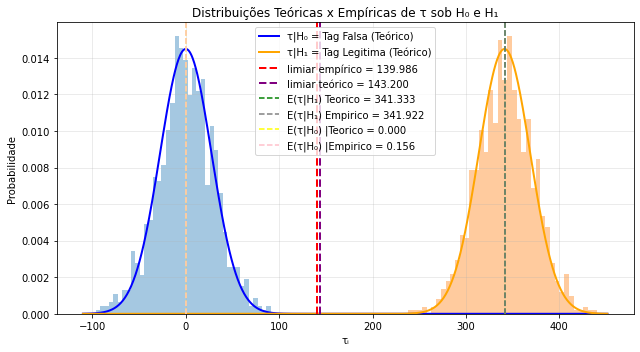

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def plot_hist_teorico_empirico(K, L, N, snr_db, eta, rho_s):
    rho_t = np.sqrt((1 - rho_s**2) * 3)         
    SNR = 10**(snr_db / 10)
    sigma2tag = 1/3                               
    sigma2v = (sigma2tag * L) / (SNR * rho_t**2) 
    tau_teorico = thresh(np.sqrt(sigma2v), 0, eta)  # limiar teórico
    # Médias teóricas 
    mu_H0 = 0
    mu_H1 = L / 3

    # Intervalo para desenhar as PDFs
    min_val = min(mu_H0 - 4*np.sqrt(sigma2v), mu_H1 - 4*np.sqrt(sigma2v))
    max_val = max(mu_H0 + 4*np.sqrt(sigma2v), mu_H1 + 4*np.sqrt(sigma2v))
    x = np.linspace(min_val, max_val, N)

    pdf_H0 = norm.pdf(x, loc=mu_H0, scale=np.sqrt(sigma2v))
    pdf_H1 = norm.pdf(x, loc=mu_H1, scale=np.sqrt(sigma2v))

    # ---- Simulação Monte Carlo ----
    chave = np.random.randint(0, 2, K)
    sigma2w, noise = gen_noise(snr_db, L)  # ruído adicionado ao sinal
    stat_H1, stat_H0, threshold = simulate_hypothesis_test(L, K, N, rho_s, snr_db, chave, sigma2w, eta)

    # ---- Plot único (Teórico + Empírico) ----
    plt.figure(figsize=(9,5))

    # Histogramas empíricos normalizados
    plt.hist(stat_H0, bins=40, density=True, alpha=0.4, color='tab:blue')
    plt.hist(stat_H1, bins=40, density=True, alpha=0.4, color='tab:orange')

    # Densidades teóricas sobrepostas
    plt.plot(x, pdf_H0, color='blue', linewidth=2, label='τ|H₀ = Tag Falsa (Teórico)')
    plt.plot(x, pdf_H1, color='orange', linewidth=2, label='τ|H₁ = Tag Legitima (Teórico)')

    # Linhas de referência
    plt.axvline(np.mean(threshold), color="red", linestyle="--", linewidth=2,
                label=f"limiar empírico = {np.mean(threshold):.3f}")
    plt.axvline(tau_teorico, color="purple", linestyle="--", linewidth=2,
                label=f"limiar teórico = {tau_teorico:.3f}")
    plt.axvline(mu_H1, color="green", linestyle="--", linewidth=1.5, label=f"E(τ|H₁) Teorico = {mu_H1:.3f}")
    plt.axvline(np.mean(stat_H1), color="grey", linestyle="--", linewidth=1.5, label=f"E(τ|H₁) Empirico = {np.mean(stat_H1):.3f}")
    plt.axvline(mu_H0, color="yellow", linestyle="--", linewidth=1.5, label=f"E(τ|H₀) |Teorico = {mu_H0:.3f}")
    plt.axvline(np.mean(stat_H0), color="pink", linestyle="--", linewidth=1.5, label=f"E(τ|H₀) |Empirico = {np.mean(stat_H0):.3f}")

    # Formatação do gráfico
    plt.title("Distribuições Teóricas x Empíricas de τ sob H₀ e H₁")
    plt.xlabel("τᵢ")
    plt.ylabel("Probabilidade")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_hist_teorico_empirico(1056, 1024, 1000, 10, 0.0000001, np.sqrt(0.985))

##Trade-offs

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, FormatStrFormatter
from tqdm.notebook import tqdm
def fnr_vs_L_theoretical(K, N, snr_db, eta, rho_s):
    rho_t = np.sqrt((1 - rho_s**2)*3)
    SNR = 10**(snr_db / 10)
    L_max = K
    L_values = range(32, L_max, 32)  # Valores de L de 32 até L_max, passo de 32
    fnr_prob = []
    tau_H0 =np.zeros((N,1))
    for L in tqdm(L_values, desc="Calculando Prob Falso Negativo teórico", unit="L"):
        #for n in range(N):
        #    chave= np.random.randint(0, 2, K) 
        #    bits_msg, bpsk_msg = modulator_bpsk(K-32)
        #    tag_legit = generate_tag(K-32,K, bits_msg, chave)
            #TAG FAKE#
        #    chave= np.random.randint(0, 2, K)
        #    x0 = np.random.uniform(-1, 1)
        #    tag_fake = generate_tag(K-32, K, bits_msg, chave,x0)
            #correlação para H0
        #    tau_H0[n] = np.sum(tag_fake*tag_legit)
        sigma2tag = (1/3)
        sigma2v= (sigma2tag*L)/(SNR*rho_t**2)
        tau = thresh(np.sqrt(sigma2v),0,eta) # a media de tau|H0 pode nao ser zero (caso de tags totalmente descorrelacionadas)
        prob = ((1-Qfunc((tau - (L/3)) / np.sqrt(sigma2v))))
            #Beta Teorico
        fnr_prob.append(prob)

    return fnr_prob


In [15]:
def fnr_vs_L_MonteCarlo(K, N, snr_db, eta, rho_s):
    L_max = K
    L_values = range(32, L_max, 32)  # Valores de L de 32 até L_max, passo de 32
    fnr_values = []

    for L in tqdm(L_values, desc="Calculando FNR Monte Carlo", unit="L"):
        fnr = 0
        for i in range(50):
            chave= np.random.randint(0, 2, L+32) #uma chave para cada uma das 50 simulações para cada valor de L
            sigma2w, noise = gen_noise(snr_db, L) # calcula a variancia do ruido inserido na mensagem
            #-------------------------------Simulação Monte Carlo - Numerical------------------------------------#
            stat_H1, stat_H0, thresh = simulate_hypothesis_test(L, L+32, N, rho_s, snr_db, chave, sigma2w, eta)
            #tau= find_threshold_to_reduce_fp(stat_H1, stat_H0, eta)
            y_true = np.concatenate([np.ones(len(stat_H1)), np.zeros(len(stat_H0))])
            y_scores = np.concatenate([stat_H1, stat_H0])
            tau_vec = np.array([thresh[i % len(thresh)] for i in range(len(y_scores))])
            y_pred = (y_scores >= tau_vec).astype(int)
            cm = confusion_matrix(y_true, y_pred, labels=[0,1])
            TN, FP, FN, TP = cm.ravel()
            fnr+= (FN/len(stat_H1))/50
            #cm_normalized = cm.astype('float') / len(stat_H0)
        fnr_values.append(fnr)

    return fnr_values

In [16]:
auth_prob = fnr_vs_L_theoretical(512, 10**3, 10, 0.0000001, np.sqrt(0.985))
np.savez("teorico_tagFalsa_0.npz", auth_prob=auth_prob)

Calculando Prob Falso Negativo teórico:   0%|          | 0/15 [00:00<?, ?L/s]

In [17]:
fnr_values = fnr_vs_L_MonteCarlo(512, 10**3, 10, 0.0000001, np.sqrt(0.985))
np.savez("fnr_MonteCarlo_tagFalsa.npz", fnr_values=fnr_values)

Calculando FNR Monte Carlo:   0%|          | 0/15 [00:00<?, ?L/s]

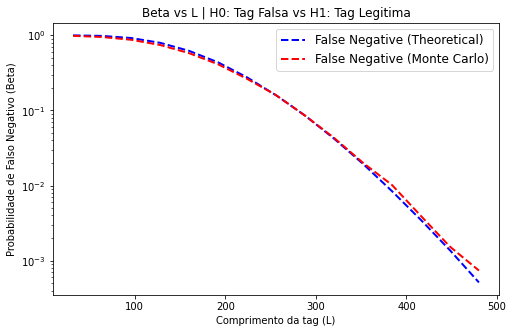

In [18]:
L_values = range(32, 512, 32)
auth_prob = np.load("teorico_tagFalsa_0.npz")["auth_prob"]
fnr_values = np.load("fnr_MonteCarlo_tagFalsa.npz")["fnr_values"]
# Plot
plt.figure(figsize=(8, 5))
plt.semilogy(L_values, auth_prob,  '--b', linewidth=2, label='False Negative (Theoretical)')
plt.semilogy(L_values, fnr_values, '--r', linewidth=2, label='False Negative (Monte Carlo)')
plt.xlabel("Comprimento da tag (L)")
plt.ylabel("Probabilidade de Falso Negativo (Beta)")
plt.title("Beta vs L | H0: Tag Falsa vs H1: Tag Legitima")
plt.legend(loc='best', fontsize=12, frameon=True)
plt.show()

In [19]:
"""# ====== Plot ======

 """

'# ====== Plot ======\n\n '